Load the MNIST dataset

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import datetime

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Normalize pixel values to the range [0, 1].

In [2]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

Flatten the 28 x 28 images into 1-D vectors of length 784

In [3]:
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

Build a baseline ANN model using Dense layers.

ReLU (Hidden Layers): It prevents the vanishing gradient problem. This ensures the gradients do not shrink to zero during backpropagation, allowing the optimizer to effectively update the weights.

Softmax (Output Layer): It converts the raw network outputs into a strict probability distribution. It ensures the predictions across the 10 distinct digit classes are between 0 and 1, and sum to exactly 1.

In [4]:
def build_model(lr=0.001):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

Compile the model with an optimizer, loss function, and metric.

In [5]:
def build_model(lr=0.001):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Train the model while manually logging hyperparameters and results.

In [6]:
experiment_log = []

def run_experiment(exp_id, lr, epochs, batch_size):
    model = build_model(lr)

    start = datetime.datetime.now()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    duration = (datetime.datetime.now() - start).total_seconds()

    experiment_log.append({
        'exp_id': exp_id,
        'learning_rate': lr,
        'epochs': epochs,
        'batch_size': batch_size,
        'val_accuracy': round(max(history.history['val_accuracy']), 4),
        'test_accuracy': round(test_acc, 4),
        'training_time_sec': round(duration, 2)
    })

    return model

In [7]:
run_experiment('EXP-01', lr=0.001, epochs=10, batch_size=32)
run_experiment('EXP-02', lr=0.01, epochs=10, batch_size=32)
run_experiment('EXP-03', lr=0.0001, epochs=10, batch_size=64)

log_df = pd.DataFrame(experiment_log)
log_df.to_csv('experiment_log.csv', index=False)
print(log_df)

   exp_id  learning_rate  epochs  batch_size  val_accuracy  test_accuracy  \
0  EXP-01         0.0010      10          32        0.9818         0.9792   
1  EXP-02         0.0100      10          32        0.9702         0.9651   
2  EXP-03         0.0001      10          64        0.9690         0.9628   

   training_time_sec  
0              54.04  
1              52.01  
2              31.00  


In [8]:
import cv2
import numpy as np

# 1. Capture the trained model in a variable
final_model = run_experiment('EXP-03', lr=0.0001, epochs=10, batch_size=64)

# 2. Build the preprocessing pipeline for a random image
def predict_custom_image(image_path, model):
    # Read the image as single-channel grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Force resize to exact 28x28 dimensions
    img_resized = cv2.resize(img, (28, 28))

    # Invert colors (MNIST requires white text on black background)
    img_inverted = cv2.bitwise_not(img_resized)

    # Normalize pixel values to the required [0, 1] range
    img_normalized = img_inverted.astype('float32') / 255.0

    # Flatten to match the expected 1-D vector of length 784
    img_flattened = img_normalized.reshape(1, 784)

    # Run inference
    predictions = model.predict(img_flattened)
    predicted_class = np.argmax(predictions)

    return predicted_class

# Example usage:
# prediction = predict_custom_image("my_random_digit.png", final_model)

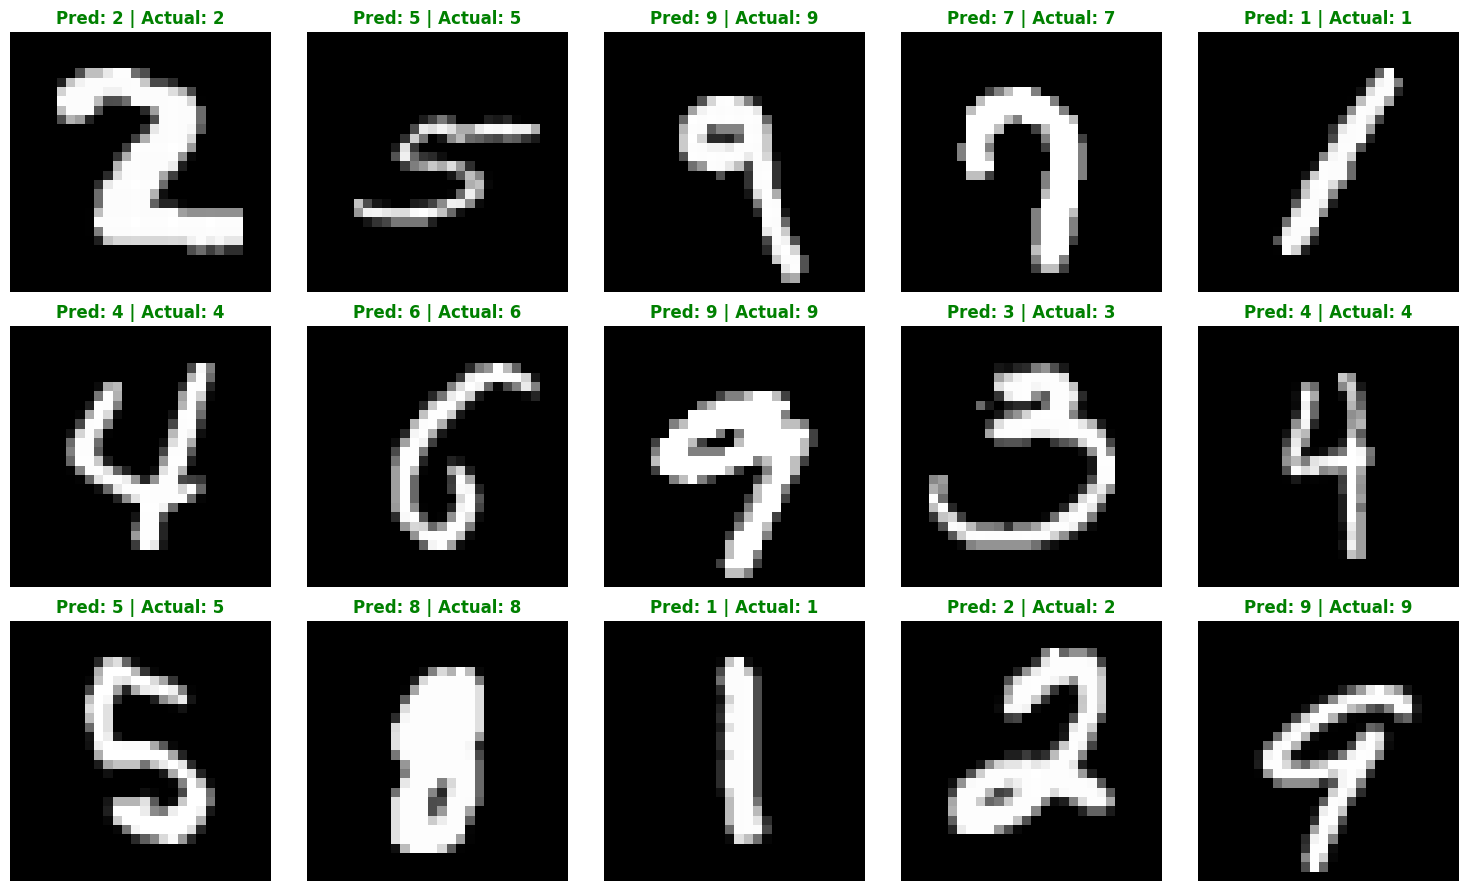

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_test_predictions(model, X_test, y_test, num_samples=15):
    # 1. Run inference on the test dataset
    raw_predictions = model.predict(X_test, verbose=0)

    # 2. Extract class index with highest probability (Softmax output -> Class label)
    predicted_labels = np.argmax(raw_predictions, axis=1)

    # 3. Randomly sample indices from the test set
    sample_indices = np.random.choice(len(X_test), size=num_samples, replace=False)

    # 4. Configure plotting grid
    cols = 5
    rows = (num_samples + cols - 1) // cols
    plt.figure(figsize=(15, 3 * rows))

    for i, idx in enumerate(sample_indices):
        plt.subplot(rows, cols, i + 1)

        # Reshape the 1D (784,) vector back to a 2D (28, 28) image matrix
        img = X_test[idx].reshape(28, 28)

        actual = y_test[idx]
        predicted = predicted_labels[idx]

        # Color-code correctly classified vs misclassified images
        color = 'green' if predicted == actual else 'red'

        plt.imshow(img, cmap='gray')
        plt.title(f"Pred: {predicted} | Actual: {actual}", color=color, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualizer using your trained model instance
plot_test_predictions(final_model, X_test, y_test, num_samples=15)